In [1]:
import pandas as pd

In [331]:
multisimo_df_with_annotations = pd.read_csv("/u/sebono/conversational_dominance/data/processed/multisimo/transcript_dominance.csv")
multisimo_df_with_annotations.head()

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,[MOD]: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,[MOD] Ok hello we are going to play a quiz. [...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"[MOD]: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"[MOD]: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"[MOD]: [MOD]: Ok. So welcome, thank you very m...",P016,P017


In [724]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [725]:
from compute_perplexity_dims import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

In [726]:
multisimo_df_with_annotations.iloc[0]["file_name"]

'S02'

In [759]:
full_dialog = multisimo_df_with_annotations.iloc[0]["file_content"]
pattern = r'\[(?:SPK[0-9]|MOD)\]'

In [765]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

In [766]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [767]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [768]:
dialog_lines = full_dialog.replace("[", '\n[').split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (4945 > 1024). Running this sequence through the model will result in indexing errors


In [769]:
## Inverting labels!
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = False)

✅ Token mapping check passed.


In [770]:
# P1 - baseline(P1) -- random shuffling of tokens
original_dialog_p1 = compute_p1(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p1 = compute_p1(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

  3%|████▋                                                                                                                                                    | 169/5444 [00:02<01:12, 73.00it/s]

KeyboardInterrupt



In [410]:
reordered_shuffled_dialog_data_p1 = reorder_tokens(original_dialog_p1, shuffled_dialog_p1, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P1")

In [411]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_scores = np.abs(np.asarray(original_dialog_p1) - np.asarray(reordered_shuffled_dialog_data_p1))
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)

In [412]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = True)

✅ Token mapping check passed.


In [413]:
# P2 - Baseline(P2) -- random shuffling of turns
original_dialog_p2 = compute_p2(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p2 = compute_p2(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 34%|████████████████████████████████████████████████████▌                                                                                                     | 259/759 [00:02<00:05, 86.65it/s]


In [414]:
reordered_shuffled_dialog_data_p2 = reorder_tokens(original_dialog_p2, shuffled_dialog_p2, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

In [415]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p2_scores = np.abs(np.asarray(original_dialog_p2) - np.asarray(reordered_shuffled_dialog_data_p2))
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)

In [416]:
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, swap_percent=0.9, invert=False)

In [417]:
# P3 - baseline(P3) -- random shuffling of tokens
original_dialog_p3 = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
swapped_dialog_p3 = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 34%|████████████████████████████████████████████████████▌                                                                                                     | 259/759 [00:03<00:05, 83.65it/s]


In [418]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
reordered_swap_speaker_tokens_p3 = reorder_tokens(original_dialog_p3, swapped_dialog_p3, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [419]:
baselined_p3_scores = np.abs(np.asarray(original_dialog_p3) - np.asarray(reordered_swap_speaker_tokens_p3))
assert len(original_dialog_p3) == len(reordered_swap_speaker_tokens_p3)

### Plotting

In [527]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import plotly
import plotly.io as pio
pio.renderers.default = 'iframe'
import plotly.express as px
plotly.offline.init_notebook_mode(connected=True)
import seaborn as sns

cmp = 'algae'
def correlation_heatmap(y_cols, x_cols, full_data):
    '''
    Uses scipy.stats.spearmanr function
    Params:
    y_cols, x_cols: sets of column titles (strings)
    full_data: pandas dataframe that includes all columns listed in y_cols, x_cols
    Returns:
    corr: Spearman correlation coefficient matrix (y_cols = rows, x_cols = cols of matrix)
    fig_corr: annotated plotly heatmap of coefficients
    p: Spearman p-value matrix
    fig_p: annotated plotly heatmap of p-values
    '''
    cols = y_cols+x_cols
    all_correlations = scipy.stats.spearmanr(full_data[cols], nan_policy='omit')
    corr = all_correlations.statistic[:len(y_cols), -len(x_cols):]
    corr = pd.DataFrame(corr)
    corr.columns = x_cols
    corr.index = y_cols

    p = all_correlations.pvalue[:len(y_cols), -len(x_cols):]
    p = pd.DataFrame(p)
    p.columns = x_cols
    p.index = y_cols
    
    fig_corr = px.imshow(corr, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_r2 = px.imshow(corr**2, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_p = px.imshow(p, text_auto=True, aspect='auto', color_continuous_scale='gray_r')

    return corr, fig_corr, p, fig_p, fig_r2

In [528]:
# BEFORE
col_1 = ["p1","p2","p3"]
#all_data = pd.DataFrame({"p1":original_dialog_p1, "p2": original_dialog_p2, "p3": original_dialog_p3})
all_data = pd.read_csv("S02_multisimo_ppls_original.csv")
original_dialog_p1 = all_data["p1"]
original_dialog_p2 = all_data["p2"]
original_dialog_p3 = all_data["p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [529]:
fig_corr

In [530]:
all_data[["p1","p2","p3"]]

,p1,p2,p3
0,NaN,NaN,5.400380
1,10.901137,10.901137,5.084168
2,6.036769,8.468953,5.189841
3,9.699756,8.879220,4.883888
4,2.106189,7.185963,5.689855
...,...,...,...
4940,4.451546,0.821411,4.175676
4941,5.056927,1.417195,4.700073
4942,2.794465,1.594661,5.426446
4943,5.010406,1.980453,4.001751


In [531]:
# AFTER
col_1 = ["p1","p2","p3"]
#all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
all_data = pd.read_csv("S02_multisimo_ppls_baselined.csv")
baselined_p1_scores = np.abs(all_data["p1"])
baselined_p2_scores = np.abs(all_data["p2"])
baselined_p3_scores = np.abs(all_data["p3"])
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [532]:
fig_corr

In [533]:
from utils import compute_graph_perplexity

In [534]:
dialog_lines = full_dialog.replace("[","\n[").split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (4945 > 1024). Running this sequence through the model will result in indexing errors


In [535]:
assert len(baselined_p1_scores) == encodings.input_ids.size(1)

In [536]:
def compute_graph_perplexity(tokens_list, p1, p2, matches, names, answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens_list]
    
    # rows = int(np.ceil(np.sqrt(len(dialog))))
    rows = int(np.ceil(len(dialog)/6.0))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, 6, figsize=(30, 15))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens_list)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    # Compute global y-limits across all p1 and p2 values
    all_values = []
    prev_idx_pp = 0
    for idx in range(len(dialog)):
        idx_pp = tokens_ids_per_sentence[idx]
        p1_per_sent = p1[prev_idx_pp:idx_pp]
        p2_per_sent = p2[prev_idx_pp:idx_pp]
        all_values.extend(p1_per_sent)
        all_values.extend(p2_per_sent)
        prev_idx_pp = idx_pp

    # Filter out NaNs and compute global limits
    all_values = np.array(all_values)
    global_min = np.nanmin(all_values)
    global_max = np.nanmax(all_values)

    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            sub_tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in sub_tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            p1_name = names['p1']
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} {p1_name}')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            # ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            p2_name = names['p2']
            ax.plot(np.asarray(p2_per_sent), label=f'{patt} {p2_name}', color='g')
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

            ax.set_ylim(global_min, global_max)

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()

In [537]:
compute_graph_perplexity(token_list, original_dialog_p1, baselined_p1_scores, matches, {"p1":"p1_or","p2":"p1_base"}, answers=None)


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x7fc3008d0900> (for post_execute):



KeyboardInterrupt



Error in callback <function flush_figures at 0x7fc21c15e8e0> (for post_execute):



KeyboardInterrupt



In [538]:
def compute_dominance_per_spk(perplexity):
    prev_idx_pp = 0
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in token_list])
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in token_list]
    all_values = []
    ppls_p_spk={}
    for idx, match in enumerate(matches):
        if match not in ppls_p_spk:
            ppls_p_spk[match] = []
        for px in range(len(token_list[idx])):
            fin_idx = px + np.sum([len(l) for l in token_list[:idx]], dtype=int)
            ppls_p_spk[match].append(perplexity[fin_idx])
    return ppls_p_spk

In [569]:
original_ppls_p_spk = compute_dominance_per_spk(original_dialog_p1)

In [570]:
for match in original_ppls_p_spk.keys():
    print(f"{match} avg ppl: ", np.nansum(original_ppls_p_spk[match])/len(original_ppls_p_spk[match]))

[MOD] avg ppl:  3.0375919734966064
[SPK1] avg ppl:  2.2680090656898795
[SPK2] avg ppl:  2.1128002790175833


In [571]:
baselined_ppls_p_spk = compute_dominance_per_spk(baselined_p1_scores)

In [572]:
for match in baselined_ppls_p_spk.keys():
    print(f"{match} avg ppl: ", np.nansum(baselined_ppls_p_spk[match])/len(baselined_ppls_p_spk[match]))

[MOD] avg ppl:  4.304818922219113
[SPK1] avg ppl:  4.465540537567566
[SPK2] avg ppl:  4.5875948953628285


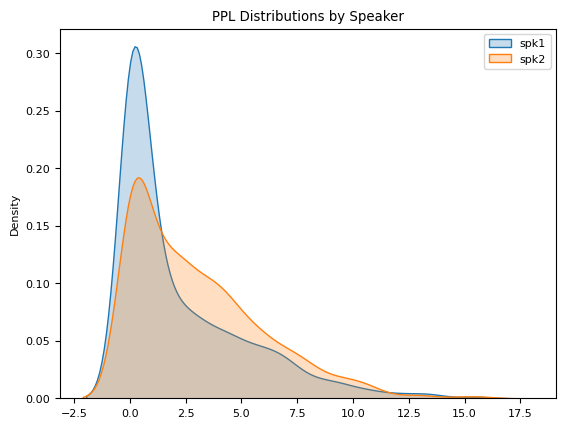

In [604]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(original_ppls_p_spk["[SPK1]"][10:], label="spk1", fill=True)
sns.kdeplot(original_ppls_p_spk["[MOD]"][10:], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [596]:
# Run statistical tests

spk1_clean = np.array(original_ppls_p_spk["[SPK1]"][10:])
spk2_clean = np.array(original_ppls_p_spk["[SPK2]"][10:])

ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

{
    "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
    "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
    "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
}

{'Kolmogorov-Smirnov': {'statistic': 0.04962323460556867,
  'p_value': 0.021274392818660188},
 'Mann-Whitney U': {'statistic': 1729309.5, 'p_value': 0.052881971592483444},
 'T-test': {'statistic': 1.4931195946551385, 'p_value': 0.1354927006813766}}

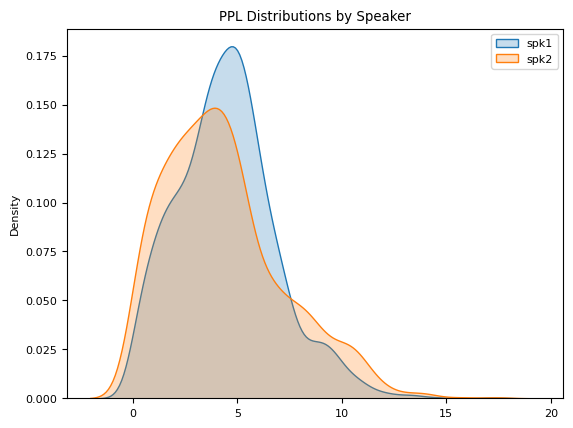

In [603]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p_spk["[SPK1]"], label="spk1", fill=True)
sns.kdeplot(baselined_ppls_p_spk["[MOD]"], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [602]:
# Run statistical tests

spk1_clean = np.array(baselined_ppls_p_spk["[MOD]"][10:])
spk2_clean = np.array(baselined_ppls_p_spk["[SPK2]"][10:])

ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

{
    "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
    "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
    "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
}

{'Kolmogorov-Smirnov': {'statistic': 0.12236922099568283,
  'p_value': 2.9114954081228096e-10},
 'Mann-Whitney U': {'statistic': 1050061.0, 'p_value': 9.247524828514925e-07},
 'T-test': {'statistic': -2.7175420347752888, 'p_value': 0.006623747827936799}}

In [623]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def rolling_kde_heatmap(ppls, window_size=50, step=10, bandwidth=0.5, vmin=None, vmax=None, title="[SPK]"):
    import numpy as np
    from scipy.stats import gaussian_kde
    import matplotlib.pyplot as plt
    import seaborn as sns

    xs = np.linspace(0, max(ppls), 100)
    densities = []

    for i in range(0, len(ppls) - window_size, step):
        window = ppls[i:i+window_size]
        kde = gaussian_kde(window, bw_method=bandwidth)
        densities.append(kde(xs))

    densities = np.array(densities)

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        densities.T, 
        xticklabels=step, 
        yticklabels=False, 
        cmap="viridis", 
        cbar=True,
        vmin=vmin, 
        vmax=vmax
    )
    plt.title(f"Rolling KDE Heatmap of PPL for {title}")
    plt.xlabel("Turn Window")
    plt.ylabel("Perplexity Bins")
    plt.show()


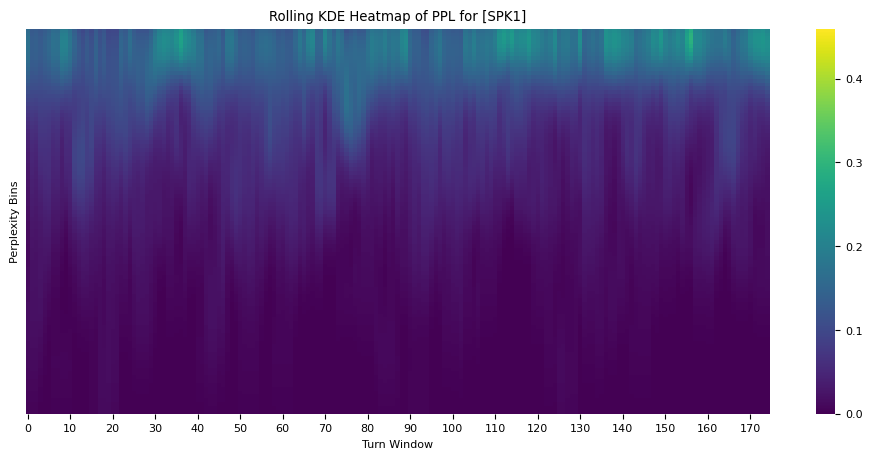

In [624]:
rolling_kde_heatmap(ppl_spk1, vmin=global_min, vmax=global_max, title="[SPK1]")

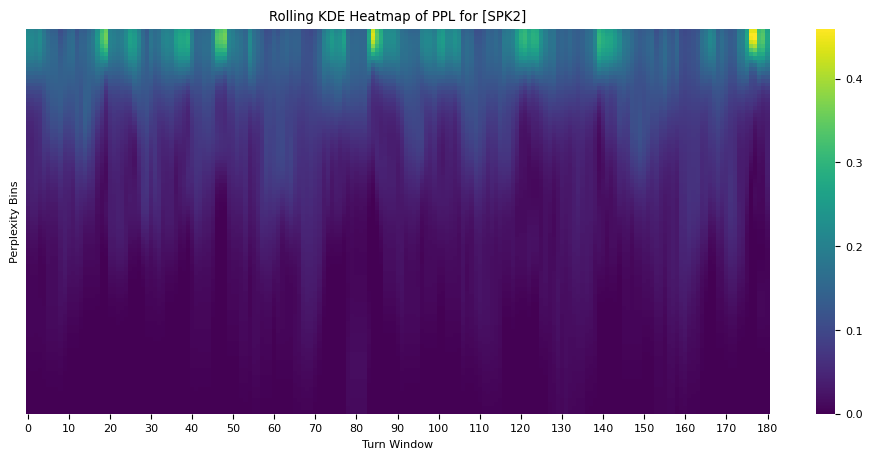

In [625]:
rolling_kde_heatmap(ppl_spk2, vmin=global_min, vmax=global_max, title="[SPK2]")

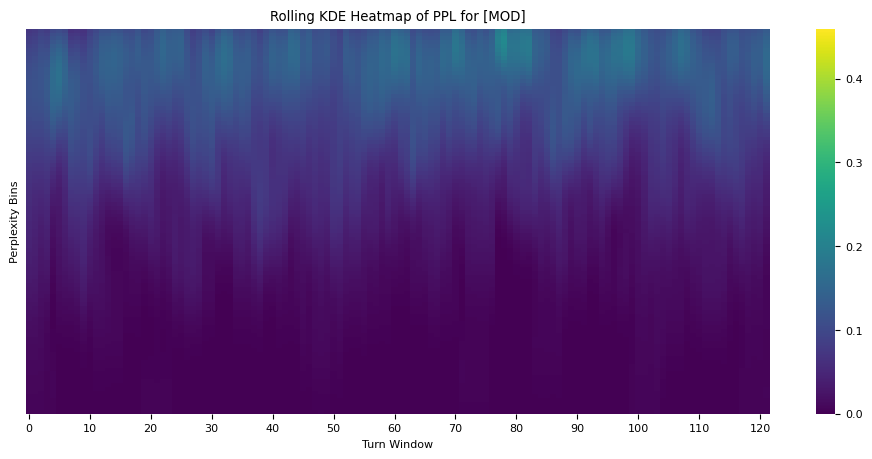

In [626]:
rolling_kde_heatmap(ppl_mod, vmin=global_min, vmax=global_max, title="[MOD]")

In [701]:
def rolling_kde_heatmap_with_turns(
    ppls,
    token_list,
    window_size=50,
    step=10,
    bandwidth=0.5,
    vmin=None,
    vmax=None,
    title="[SPK]"
):
    """
    Plots a rolling KDE heatmap over token-level perplexities and marks true turn boundaries.
    """
    ppls = np.array(ppls)
    xs = np.linspace(0, np.nanmax(ppls), 100)
    densities = []

    for i in range(0, len(ppls) - window_size, step):
        window = ppls[i:i + window_size]
        if np.isnan(window).any():
            densities.append(np.zeros_like(xs))  # pad with zeros for alignment
        else:
            kde = gaussian_kde(window, bw_method=bandwidth)
            densities.append(kde(xs))

    densities = np.array(densities)

    # Compute actual token indices of turn ends
    turn_boundaries_token_idx = np.cumsum([len(tok) for tok in token_list])[:-1]

    # Map token indices to heatmap x-axis bins
    x_bins = np.arange(0, len(ppls) - window_size, step)
    turn_boundaries_bins = [np.searchsorted(x_bins, tb) for tb in turn_boundaries_token_idx]

    # Avoid duplicates
    unique_turn_bins = sorted(set(turn_boundaries_bins))

    # Plot
    plt.figure(figsize=(12, 5))
    ax = sns.heatmap(
        densities.T,
        xticklabels=step,
        yticklabels=False,
        cmap="viridis",
        cbar=True,
        vmin=vmin,
        vmax=vmax
    )

    for xb in unique_turn_bins:
        ax.axvline(x=xb, color='white', linestyle='--', linewidth=0.5, alpha=0.7)

    plt.title(f"Rolling KDE Heatmap of PPL for {title}")
    plt.xlabel("Turn Window")
    plt.ylabel("Perplexity Bins")
    plt.tight_layout()
    plt.show()


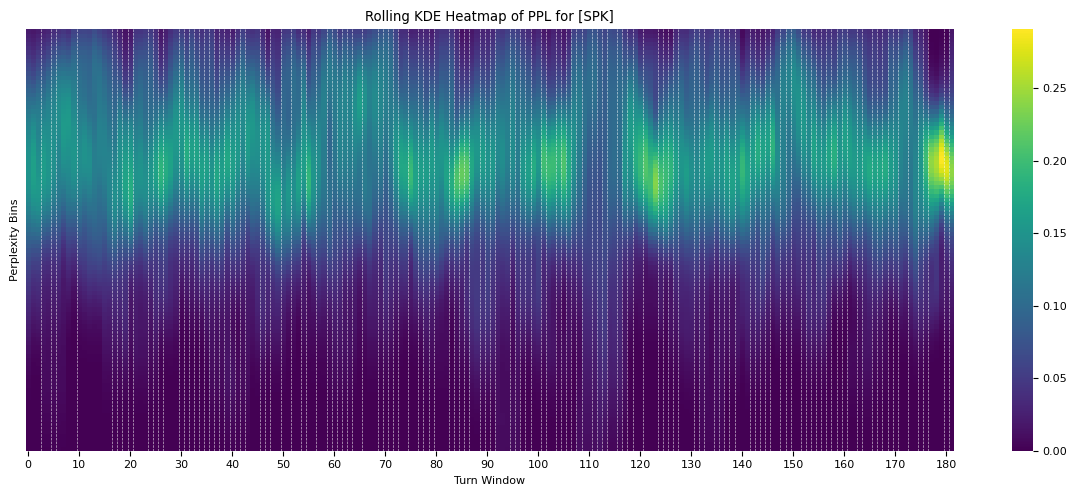

In [722]:
rolling_kde_heatmap_with_turns(token_list=token_list, ppls=baselined_ppls_p_spk['[SPK2]'])

In [730]:
import pandas as pd
candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR_gpt2-large/conversations.csv")
candor_df.head()

,file_name,file_content
0,7595d874-c1cb-4aef-918f-3c81f3a84324,<SPK0> this is Yeah. Mhm. Mhm. Yeah. Yeah. Mot...
1,66768810-879d-4e2f-b5f5-ecc67d298104,<SPK0> Uh huh uh huh. Yeah. <SPK1> Yeah. All r...
2,dc3d0ae4-8d20-4d1d-8e0c-82c85a79b26e,<SPK1> Yeah. Right. Mhm. Mhm. Mhm. Okay. Yeah....
3,fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135,<SPK0> Hi there and move away. <SPK1> mm. <SPK...
4,73c201ef-8c32-43d4-b642-dcedf4aa5c7f,<SPK0> Yeah. Okay. Yeah. Mhm. Yeah. Mhm Uh huh...


In [740]:
name_file = candor_df.iloc[0]["file_name"]
conversation = candor_df.iloc[0]["file_content"]

In [783]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = conversation.replace("<", "\n<").split("\n")[300:700]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

In [811]:
## Inverting labels!
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = False)

# P1 - baseline(P1) -- random shuffling of tokens
original_dialog_p1 = compute_p1(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p1 = compute_p1(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
reordered_shuffled_dialog_data_p1 = reorder_tokens(original_dialog_p1, shuffled_dialog_p1, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P1")

✅ Token mapping check passed.


 91%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎             | 5044/5544 [02:30<00:14, 33.58it/s]


In [813]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = True)
# P2 - Baseline(P2) -- random shuffling of turns
original_dialog_p2 = compute_p2(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p2 = compute_p2(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
reordered_shuffled_dialog_data_p2 = reorder_tokens(original_dialog_p2, shuffled_dialog_p2, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

✅ Token mapping check passed.


 91%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎             | 5044/5544 [02:30<00:14, 33.47it/s]


In [814]:
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, swap_percent=0.9, invert=False)
# P3 - baseline(P3) -- random shuffling of tokens
original_dialog_p3 = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
swapped_dialog_p3 = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
reordered_swap_speaker_tokens_p3 = reorder_tokens(original_dialog_p3, swapped_dialog_p3, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

 91%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎             | 5044/5544 [02:31<00:15, 33.19it/s]


In [908]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_scores = np.asarray(original_dialog_p1) - np.asarray(reordered_shuffled_dialog_data_p1)
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)

original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p2_scores = np.asarray(original_dialog_p2) - np.asarray(reordered_shuffled_dialog_data_p2)
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)

baselined_p3_scores = np.asarray(original_dialog_p3) - np.asarray(reordered_swap_speaker_tokens_p3)
assert len(original_dialog_p3) == len(reordered_swap_speaker_tokens_p3)

In [909]:
all_data = pd.DataFrame({'baselined_p1_scores':baselined_p1_scores, 'baselined_p2_scores':baselined_p2_scores, 'baselined_p3_scores':baselined_p3_scores, 'original_dialog_p1':original_dialog_p1, 'original_dialog_p2':original_dialog_p2,'original_dialog_p3':original_dialog_p3})
all_data.to_csv(f"{candor_df.iloc[0]['file_name']}_candor_ppl.csv", index=False)

In [910]:
baselined_ppls_p2_spk = compute_dominance_per_spk(baselined_p2_scores)
baselined_ppls_p3_spk = compute_dominance_per_spk(baselined_p3_scores)

In [911]:
# Run statistical tests
def compute_significance(original_ppls_p_spk):
    spk1_clean = np.array(original_ppls_p_spk["<SPK0>"])
    spk2_clean = np.array(original_ppls_p_spk["<SPK1>"])

    ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
    ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

    ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
    mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
    tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

    return {
        "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
        "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
        "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
    }

In [912]:
compute_significance(baselined_ppls_p2_spk), compute_significance(baselined_ppls_p3_spk) 

({'Kolmogorov-Smirnov': {'statistic': 0.04501759164680513,
   'p_value': 0.011716299867592412},
  'Mann-Whitney U': {'statistic': 3105928.5, 'p_value': 0.20099914696931753},
  'T-test': {'statistic': -1.645880597990431, 'p_value': 0.09985074805712257}},
 {'Kolmogorov-Smirnov': {'statistic': 0.15424354429534368,
   'p_value': 1.3704021243709714e-26},
  'Mann-Whitney U': {'statistic': 3385221.5,
   'p_value': 4.4847439169549664e-05},
  'T-test': {'statistic': 8.876509915316957, 'p_value': 9.52148600138857e-19}})

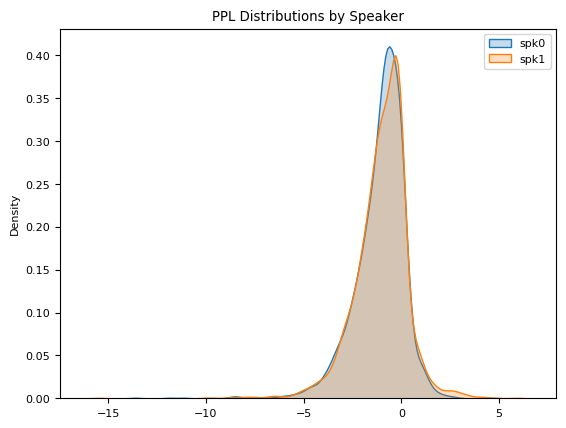

In [913]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p2_spk["<SPK0>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p2_spk["<SPK1>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

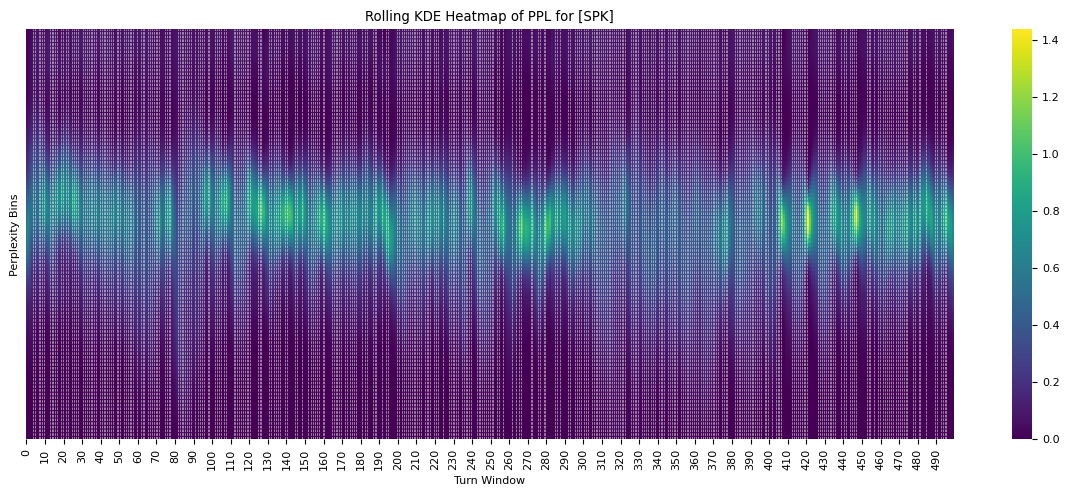

In [914]:
rolling_kde_heatmap_with_turns(token_list=token_list, ppls=original_dialog_p3)

In [915]:
tokenizer.decode(encodings.input_ids[0][4000:4100],skip_special_tokens=True)

"SPK0> it's a little too cloudy but  <SPK1> Uh huh  <SPK0> it's still, it  <SPK1> Uh  <SPK0> offers a lot  <SPK1> huh  <SPK0> and it's not expensive.  <SPK1> Right. Yeah, that's a big thing um that I'm looking forward to here actually because in Wisconsin, during the winter, even if it"

In [916]:
tokenizer.decode(encodings.input_ids[0][4200:4300],skip_special_tokens=True)

".  <SPK1> here and there. Yeah, so like today it's cloudy and that, but from what I understand during the winter the sun will be out, which like to me like I get really lazy and tired and I just don't want to do anything when it's cloudy off.  <SPK0> Yeah. Yeah, no, same here,  <SPK1> Uh huh.  <SPK0> it kind  <SPK1>"

In [917]:
# AFTER
col_1 = ["p2","p3"]
all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
baselined_p2_scores = np.abs(all_data["p2"])
baselined_p3_scores = np.abs(all_data["p3"])
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [918]:
fig_corr